In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('/content/Zomato data .csv')
print(df)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [8]:
pd.isnull(df).sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [9]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

Convert the datatype of columns


In [10]:
def handleRate(rate):
  if isinstance(rate,str):
    rate=rate.split('/')[0]
    rate=rate.replace(',','')
    return float(rate)
  return rate

In [11]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


1.What type of restaurant do the majority of customer order from

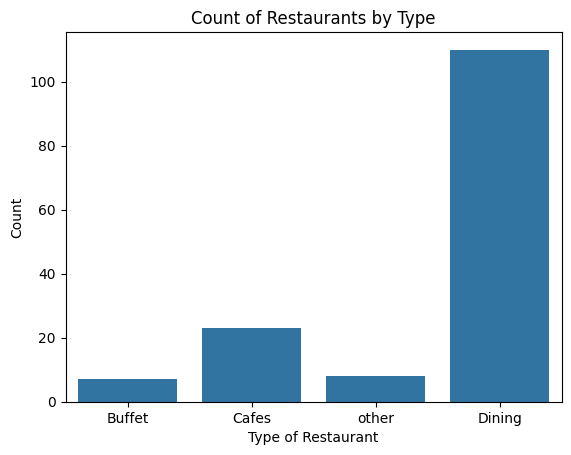

In [16]:
c=('red','blue', 'pink', 'yellow')
sns.countplot(x='listed_in(type)' , data=df)
plt.xlabel('Type of Restaurant')
plt.ylabel('Count')
plt.title('Count of Restaurants by Type')
plt.show()

conclusion : Dinning type of restaurant majority of the customer order from.

How many votes has each type of restaurant received from customer?

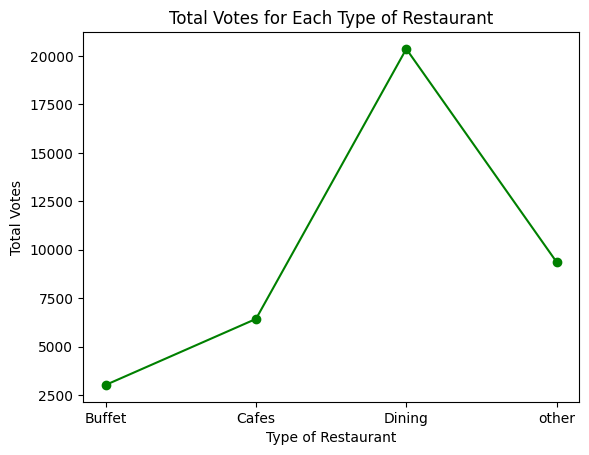

In [18]:
from itertools import groupby
group_data=df.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes':group_data})
plt.plot(result , c='green',marker='o')
plt.xlabel('Type of Restaurant')
plt.ylabel('Total Votes')
plt.title('Total Votes for Each Type of Restaurant')
plt.show()

Conclusion : Dinning type of restaurant got the maximum votes recevied from customer.

What are the rating that the majority of restaurant have received?

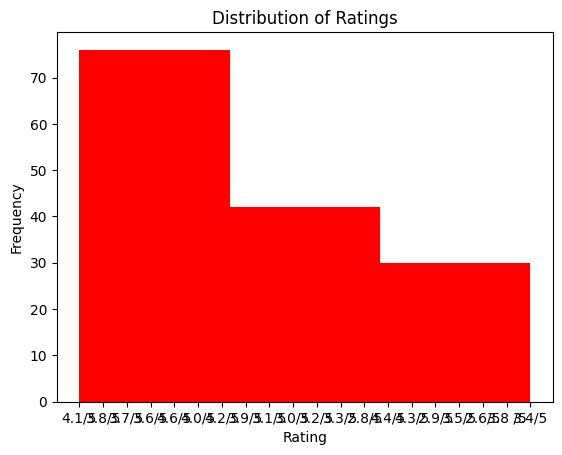

In [25]:
plt.hist(df['rate'], bins=5 , color='red')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.show()

zomato has observed that most couples order most of their food online , what is their average spending on each order.

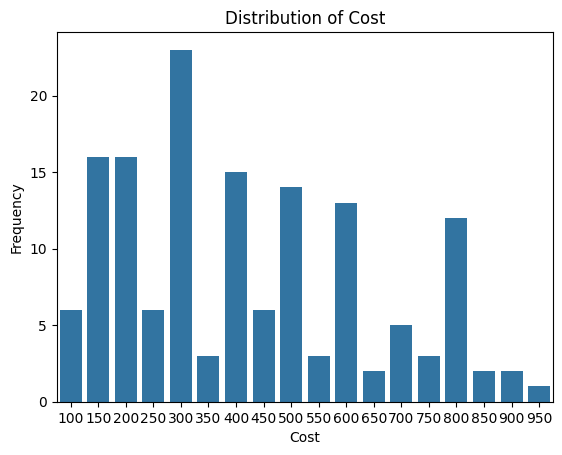

In [26]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)
plt.xlabel('Cost')
plt.ylabel('Frequency')
plt.title('Distribution of Cost')
plt.show()

The average cost of most of the couples order is rs 300

Which mode has received the maximum rating ?

In [28]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


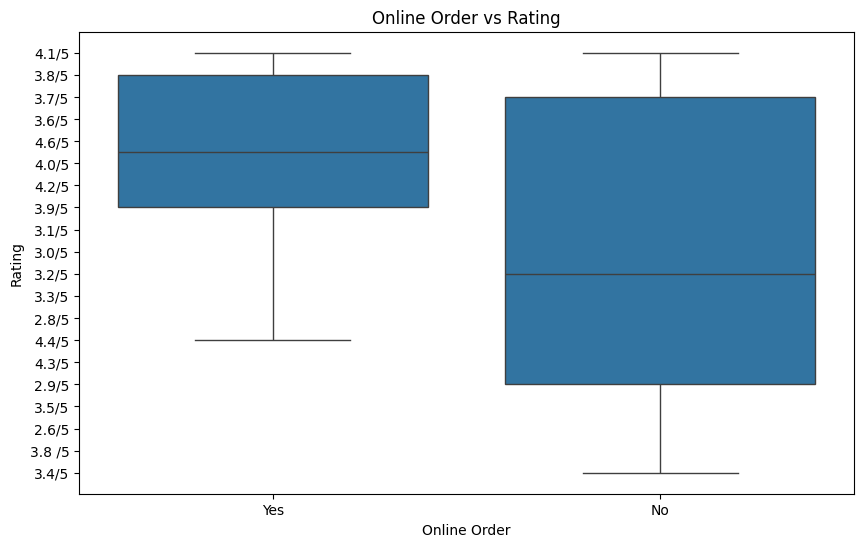

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(x='online_order', y='rate', data=df)
plt.xlabel('Online Order')
plt.ylabel('Rating')
plt.title('Online Order vs Rating')
plt.show()

Most of the people order online food .

What type of restuarant received more offline order, so the zomato can provide customers with some good offers?

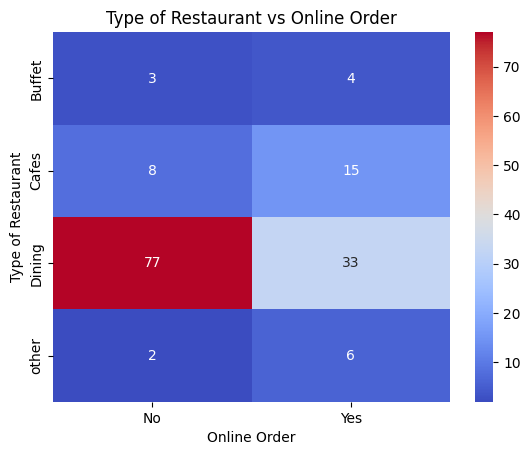

In [33]:
pivot_table=df.pivot_table(index='listed_in(type)',columns='online_order',values='rate',aggfunc='count')
sns.heatmap(pivot_table,annot=True,cmap='coolwarm')
plt.xlabel('Online Order')
plt.ylabel('Type of Restaurant')
plt.title('Type of Restaurant vs Online Order')
plt.show()